# Análisis de Temporada — Premier League 2015/16

Base de datos SQLite con todos los partidos y eventos de la temporada.
Consultas SQL para responder preguntas estadísticas a nivel de temporada completa.

In [2]:
# Paso 1 — Importar librerías
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
from statsbombpy import sb

warnings.filterwarnings('ignore')
DB_PATH = 'premier_league_1516.db'
print('Librerías cargadas.')

Librerías cargadas.


In [3]:
# Paso 2 — Descargar todos los partidos de Premier League 2015/16
partidos = sb.matches(competition_id=2, season_id=27)
print(f'Total partidos: {len(partidos)}')
print(partidos[['match_id','home_team','away_team','home_score','away_score','match_date']].head())

Total partidos: 380
   match_id             home_team        away_team  home_score  away_score  \
0   3754058        Leicester City  AFC Bournemouth           0           0   
1   3754245  West Bromwich Albion       Sunderland           1           0   
2   3754136      Newcastle United      Aston Villa           1           1   
3   3754037               Everton  AFC Bournemouth           2           1   
4   3754039        Crystal Palace          Watford           1           2   

   match_date  
0  2016-01-02  
1  2015-10-17  
2  2015-12-19  
3  2016-04-30  
4  2016-02-13  


In [4]:
# Paso 3 — Crear base de datos SQLite y tabla de partidos
conn = sqlite3.connect(DB_PATH)

# Guardar tabla de partidos
cols = ['match_id','home_team','away_team','home_score','away_score','match_date']
partidos[cols].to_sql('matches', conn, if_exists='replace', index=False)

print(f'Tabla matches creada con {len(partidos)} filas.')
print('Base de datos:', DB_PATH)

Tabla matches creada con 380 filas.
Base de datos: premier_league_1516.db


In [5]:
# Paso 4 — Descargar eventos de todos los partidos y guardarlos en SQLite
# ⚠️  Esto descarga ~380 partidos — puede tardar 5-10 minutos.
# Una vez ejecutado, los datos quedan en el archivo .db y no hay que repetirlo.

import os

# Si la tabla ya existe y tiene datos, saltar la descarga
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='events'")
tabla_existe = cursor.fetchone() is not None

if tabla_existe:
    count = pd.read_sql('SELECT COUNT(*) as n FROM events', conn)['n'][0]
    print(f'Tabla events ya existe con {count:,} filas. Saltando descarga.')
else:
    cols_eventos = [
        'match_id','id','index','period','minute','second',
        'team','player','type','possession_team'
    ]
    match_ids = partidos['match_id'].tolist()
    total = len(match_ids)
    todos = []

    for i, mid in enumerate(match_ids, 1):
        ev = sb.events(match_id=mid)
        ev['match_id'] = mid
        disponibles = [c for c in cols_eventos if c in ev.columns]
        todos.append(ev[disponibles])
        if i % 20 == 0 or i == total:
            print(f'  {i}/{total} partidos descargados...')

    df_eventos = pd.concat(todos, ignore_index=True)
    df_eventos.to_sql('events', conn, if_exists='replace', index=False)
    print(f'\n✅ Tabla events creada con {len(df_eventos):,} filas.')

  20/380 partidos descargados...
  40/380 partidos descargados...
  60/380 partidos descargados...
  80/380 partidos descargados...
  100/380 partidos descargados...
  120/380 partidos descargados...
  140/380 partidos descargados...
  160/380 partidos descargados...
  180/380 partidos descargados...
  200/380 partidos descargados...
  220/380 partidos descargados...
  240/380 partidos descargados...
  260/380 partidos descargados...
  280/380 partidos descargados...
  300/380 partidos descargados...
  320/380 partidos descargados...
  340/380 partidos descargados...
  360/380 partidos descargados...
  380/380 partidos descargados...

✅ Tabla events creada con 1,313,783 filas.


In [16]:
# Paso 5 — Crear tabla de tiros con xG
# Convierte location [x, y] a shot_x / shot_y para compatibilidad con SQLite.

cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='shots'")
shots_existe = cursor.fetchone() is not None

if shots_existe:
    count = pd.read_sql('SELECT COUNT(*) as n FROM shots', conn)['n'][0]
    if count > 0:
        print(f'Tabla shots ya existe con {count:,} filas. Saltando.')
    else:
        conn.execute('DROP TABLE shots')
        conn.commit()
        shots_existe = False
        print('Tabla shots vacía eliminada. Recreando...')

if not shots_existe:
    # Diagnóstico: ver qué keys devuelve split=True en el primer partido
    primer_id = partidos['match_id'].iloc[0]
    ev_test = sb.events(match_id=primer_id, split=True)
    print('Keys disponibles en split:', list(ev_test.keys())[:10])

    # Buscar el key correcto para tiros
    shot_key = next((k for k in ev_test.keys() if 'shot' in k.lower()), None)
    print(f'Key de tiros detectado: {shot_key}')

    cols_shots = ['match_id', 'minute', 'team', 'player', 'shot_outcome', 'shot_statsbomb_xg']
    todos_shots = []
    total = len(partidos)

    for i, mid in enumerate(partidos['match_id'], 1):
        ev_split = sb.events(match_id=mid, split=True)
        shots = ev_split.get(shot_key, pd.DataFrame()).copy()

        if len(shots) == 0:
            continue

        shots['match_id'] = mid

        if 'location' in shots.columns:
            shots['shot_x'] = shots['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
            shots['shot_y'] = shots['location'].apply(lambda l: l[1] if isinstance(l, list) else None)

        disponibles = [c for c in cols_shots + ['shot_x', 'shot_y'] if c in shots.columns]
        todos_shots.append(shots[disponibles])

        if i % 50 == 0 or i == total:
            print(f'  {i}/{total} partidos procesados...')

    if todos_shots:
        df_shots = pd.concat(todos_shots, ignore_index=True)
        df_shots.to_sql('shots', conn, if_exists='replace', index=False)
        print(f'\u2705 Tabla shots creada con {len(df_shots):,} filas.')
    else:
        print('\u26a0\ufe0f No se encontraron tiros. Revisa los keys disponibles arriba.')

Keys disponibles en split: ['starting_xis', 'half_starts', 'passes', 'ball_receipts', 'carrys', 'pressures', 'dispossesseds', 'duels', 'shots', 'blocks']
Key de tiros detectado: shots
  50/380 partidos procesados...
  100/380 partidos procesados...
  150/380 partidos procesados...
  200/380 partidos procesados...
  250/380 partidos procesados...
  300/380 partidos procesados...
  350/380 partidos procesados...
  380/380 partidos procesados...
✅ Tabla shots creada con 9,908 filas.


In [17]:
# Paso 6 — Verificar tablas en la base de datos
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tablas disponibles:')
for t in tablas['name']:
    n = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', conn)['n'][0]
    print(f'  {t}: {n:,} filas')

Tablas disponibles:
  matches: 380 filas
  events: 1,313,783 filas
  shots: 9,908 filas


## SQL 1 — Top Goleadores de la Temporada

                           player              team  goles
                       Harry Kane Tottenham Hotspur     25
                      Jamie Vardy    Leicester City     24
Sergio Leonel Agüero del Castillo   Manchester City     24
             Romelu Lukaku Menama           Everton     18
                     Riyad Mahrez    Leicester City     17
                   Olivier Giroud           Arsenal     16
                    Jermain Defoe        Sunderland     15
                Odion Jude Ighalo           Watford     15
 Alexis Alejandro Sánchez Sánchez           Arsenal     13
                      Troy Deeney           Watford     13


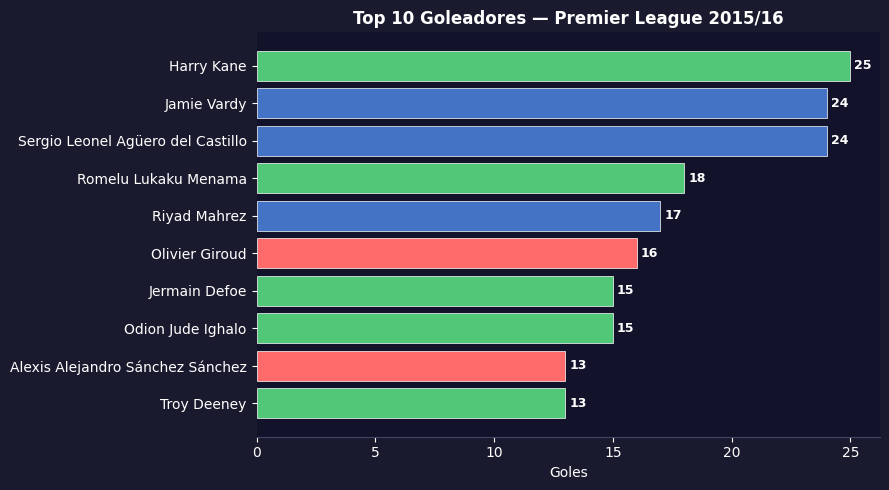

In [19]:
# SQL 1 — Top 10 goleadores de la temporada
query = """
SELECT
    player,
    team,
    COUNT(*) AS goles
FROM shots
WHERE shot_outcome = 'Goal'
GROUP BY player, team
ORDER BY goles DESC
LIMIT 10
"""
df_goleadores = pd.read_sql(query, conn)
print(df_goleadores.to_string(index=False))

plt.close('all')
os.makedirs('graficos', exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#12122a')
colores = ['#4472C4' if 'City' in t or 'United' in t else '#FF6B6B'
           if 'Liverpool' in t or 'Arsenal' in t else '#50C878'
           for t in df_goleadores['team']]
bars = ax.barh(df_goleadores['player'][::-1], df_goleadores['goles'][::-1],
               color=colores[::-1], edgecolor='white', linewidth=0.5)
ax.bar_label(bars, padding=3, color='white', fontsize=9, fontweight='bold')
ax.set_title('Top 10 Goleadores — Premier League 2015/16',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#444466')
ax.set_xlabel('Goles', color='white')
plt.tight_layout()
plt.savefig('graficos/sql_01_goleadores.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

## SQL 2 — xG Total por Equipo

                team  xg_generado  goles  eficiencia
      Leicester City        66.28     67       1.011
             Arsenal        65.14     62       0.952
     Manchester City        64.56     71       1.100
   Tottenham Hotspur        62.36     68       1.091
           Liverpool        58.37     62       1.062
     West Ham United        54.53     64       1.174
         Southampton        54.22     57       1.051
             Chelsea        53.58     55       1.027
             Everton        50.61     56       1.106
             Watford        44.08     36       0.817
          Sunderland        42.49     44       1.036
      Crystal Palace        42.38     38       0.897
   Manchester United        42.20     46       1.090
        Swansea City        42.15     41       0.973
    Newcastle United        40.67     43       1.057
          Stoke City        40.37     40       0.991
     AFC Bournemouth        40.35     43       1.066
        Norwich City        38.89     38      

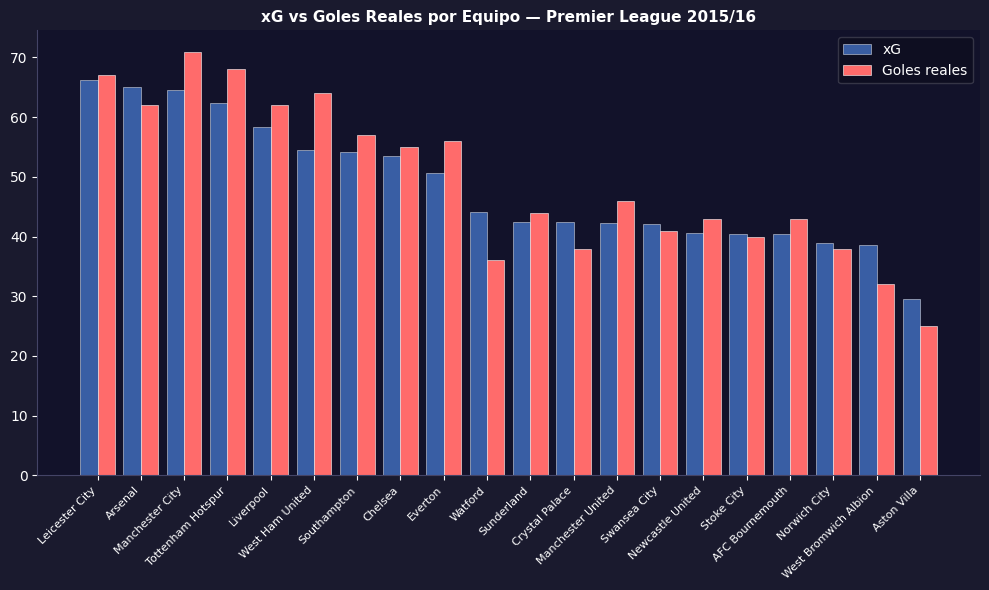

In [20]:
# SQL 2 — xG total generado y concedido por equipo en la temporada
query = """
SELECT
    team,
    ROUND(SUM(shot_statsbomb_xg), 2) AS xg_generado,
    COUNT(CASE WHEN shot_outcome = 'Goal' THEN 1 END) AS goles,
    ROUND(COUNT(CASE WHEN shot_outcome = 'Goal' THEN 1 END) * 1.0
          / SUM(shot_statsbomb_xg), 3) AS eficiencia
FROM shots
GROUP BY team
ORDER BY xg_generado DESC
"""
df_xg = pd.read_sql(query, conn)
print(df_xg.to_string(index=False))

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#12122a')
x = range(len(df_xg))
ax.bar([i - 0.2 for i in x], df_xg['xg_generado'], 0.4,
       label='xG', color='#4472C4', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.bar([i + 0.2 for i in x], df_xg['goles'], 0.4,
       label='Goles reales', color='#FF6B6B', edgecolor='white', linewidth=0.4)
ax.set_xticks(list(x))
ax.set_xticklabels(df_xg['team'], rotation=45, ha='right', color='white', fontsize=8)
ax.set_title('xG vs Goles Reales por Equipo — Premier League 2015/16',
             color='white', fontsize=11, fontweight='bold')
ax.legend(framealpha=0.2, labelcolor='white')
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#444466')
plt.tight_layout()
plt.savefig('graficos/sql_02_xg_equipos.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

## SQL 3 — Ranking de Equipos por Tipo de Evento

Top 10 — Pases:
             team  total
          Arsenal  22709
  Manchester City  22340
Manchester United  21890
        Liverpool  21464
          Chelsea  21275
Tottenham Hotspur  20624
     Swansea City  20003
          Everton  19868
  AFC Bournemouth  19406
      Southampton  17995

Top 10 — Tiros:
             team  total
Tottenham Hotspur    656
        Liverpool    635
  Manchester City    614
          Arsenal    583
  West Ham United    559
          Chelsea    535
      Southampton    527
   Leicester City    525
          Everton    498
  AFC Bournemouth    478

Top 10 — Presiones:
             team  total
        Liverpool   6540
      Aston Villa   6235
   Leicester City   6231
  AFC Bournemouth   6210
 Newcastle United   6105
Tottenham Hotspur   6021
       Sunderland   6001
          Chelsea   5812
   Crystal Palace   5786
      Southampton   5718



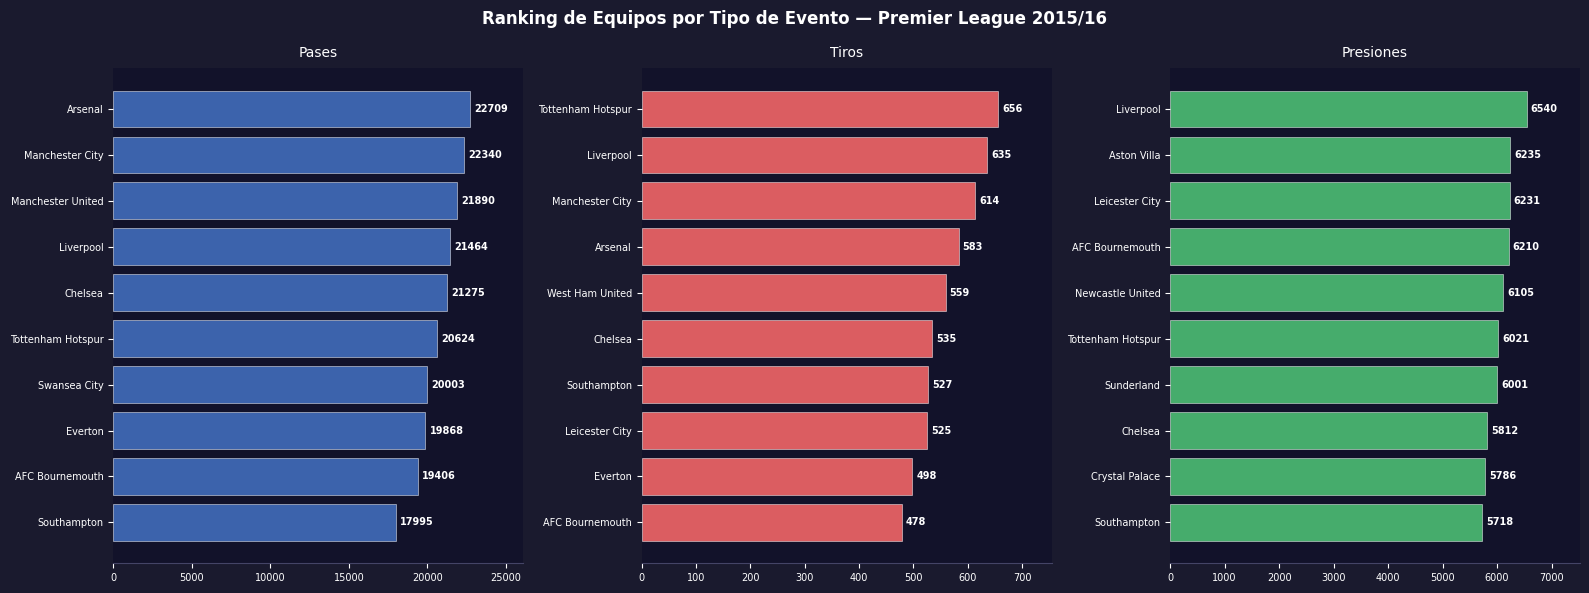

In [23]:
# SQL 3 — Ranking de Equipos por Tipo de Evento
# Tres paneles: pases, tiros y presiones — top 10 equipos en cada métrica.

tipos = [('Pass', 'Pases', '#4472C4'), ('Shot', 'Tiros', '#FF6B6B'), ('Pressure', 'Presiones', '#50C878')]
dfs = {}

for tipo, label, _ in tipos:
    query = f"""
    SELECT team, COUNT(*) AS total
    FROM events
    WHERE type = '{tipo}'
    GROUP BY team
    ORDER BY total DESC
    LIMIT 10
    """
    dfs[tipo] = pd.read_sql(query, conn)
    print(f'Top 10 — {label}:')
    print(dfs[tipo].to_string(index=False))
    print()

plt.close('all')
os.makedirs('graficos', exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Ranking de Equipos por Tipo de Evento — Premier League 2015/16',
             fontsize=12, fontweight='bold', color='white')

for ax, (tipo, label, color) in zip(axes, tipos):
    ax.set_facecolor('#12122a')
    df = dfs[tipo]
    bars = ax.barh(df['team'][::-1], df['total'][::-1],
                   color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.bar_label(bars, padding=3, color='white', fontsize=7, fontweight='bold')
    ax.set_title(label, color='white', fontsize=10, pad=8)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#444466')
    ax.set_xlim(0, df['total'].max() * 1.15)

plt.tight_layout()
plt.savefig('graficos/sql_03_ranking_equipos.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

## SQL 4 — Partidos con Más Goles

       home_team        away_team  home_score  away_score  total_goles match_date
    Norwich City        Liverpool           4           5            9 2016-01-23
         Everton       Sunderland           6           2            8 2015-11-01
Newcastle United     Norwich City           6           2            8 2015-10-18
         Everton       Stoke City           3           4            7 2015-12-28
 Manchester City Newcastle United           6           1            7 2015-10-03
  Leicester City          Arsenal           2           5            7 2015-09-26
 West Ham United  AFC Bournemouth           3           4            7 2015-08-22
 AFC Bournemouth          Everton           3           3            6 2015-11-28
 Manchester City  AFC Bournemouth           5           1            6 2015-10-17
  Leicester City       Sunderland           4           2            6 2015-08-08


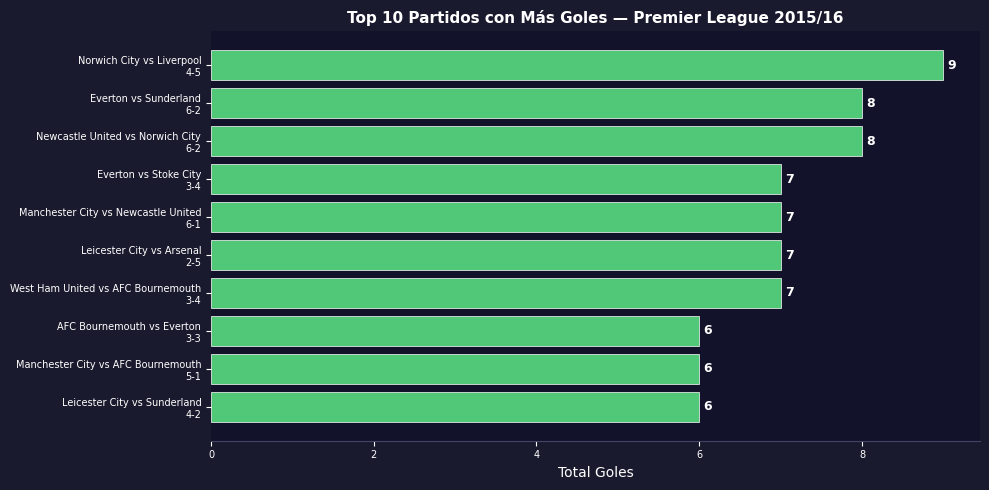

In [22]:
# SQL 4 — Top 10 partidos con más goles en la temporada
query = """
SELECT
    m.home_team,
    m.away_team,
    m.home_score,
    m.away_score,
    (m.home_score + m.away_score) AS total_goles,
    m.match_date
FROM matches m
ORDER BY total_goles DESC
LIMIT 10
"""
df_goles = pd.read_sql(query, conn)
print(df_goles.to_string(index=False))

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#12122a')
etiquetas = [f"{r['home_team']} vs {r['away_team']}\n{r['home_score']}-{r['away_score']}"
             for _, r in df_goles.iterrows()]
bars = ax.barh(etiquetas[::-1], df_goles['total_goles'][::-1],
               color='#50C878', edgecolor='white', linewidth=0.5)
ax.bar_label(bars, padding=3, color='white', fontsize=9, fontweight='bold')
ax.set_title('Top 10 Partidos con Más Goles — Premier League 2015/16',
             color='white', fontsize=11, fontweight='bold')
ax.tick_params(colors='white', labelsize=7)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#444466')
ax.set_xlabel('Total Goles', color='white')
plt.tight_layout()
plt.savefig('graficos/sql_04_partidos_mas_goles.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

In [ ]:
# Cerrar conexión a la base de datos
conn.close()
print('Conexión cerrada. Base de datos guardada en:', DB_PATH)